In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

csv_path = Path("mysql/mysql (sequential u1)/phase_summary.csv")

Sequential Benchmark

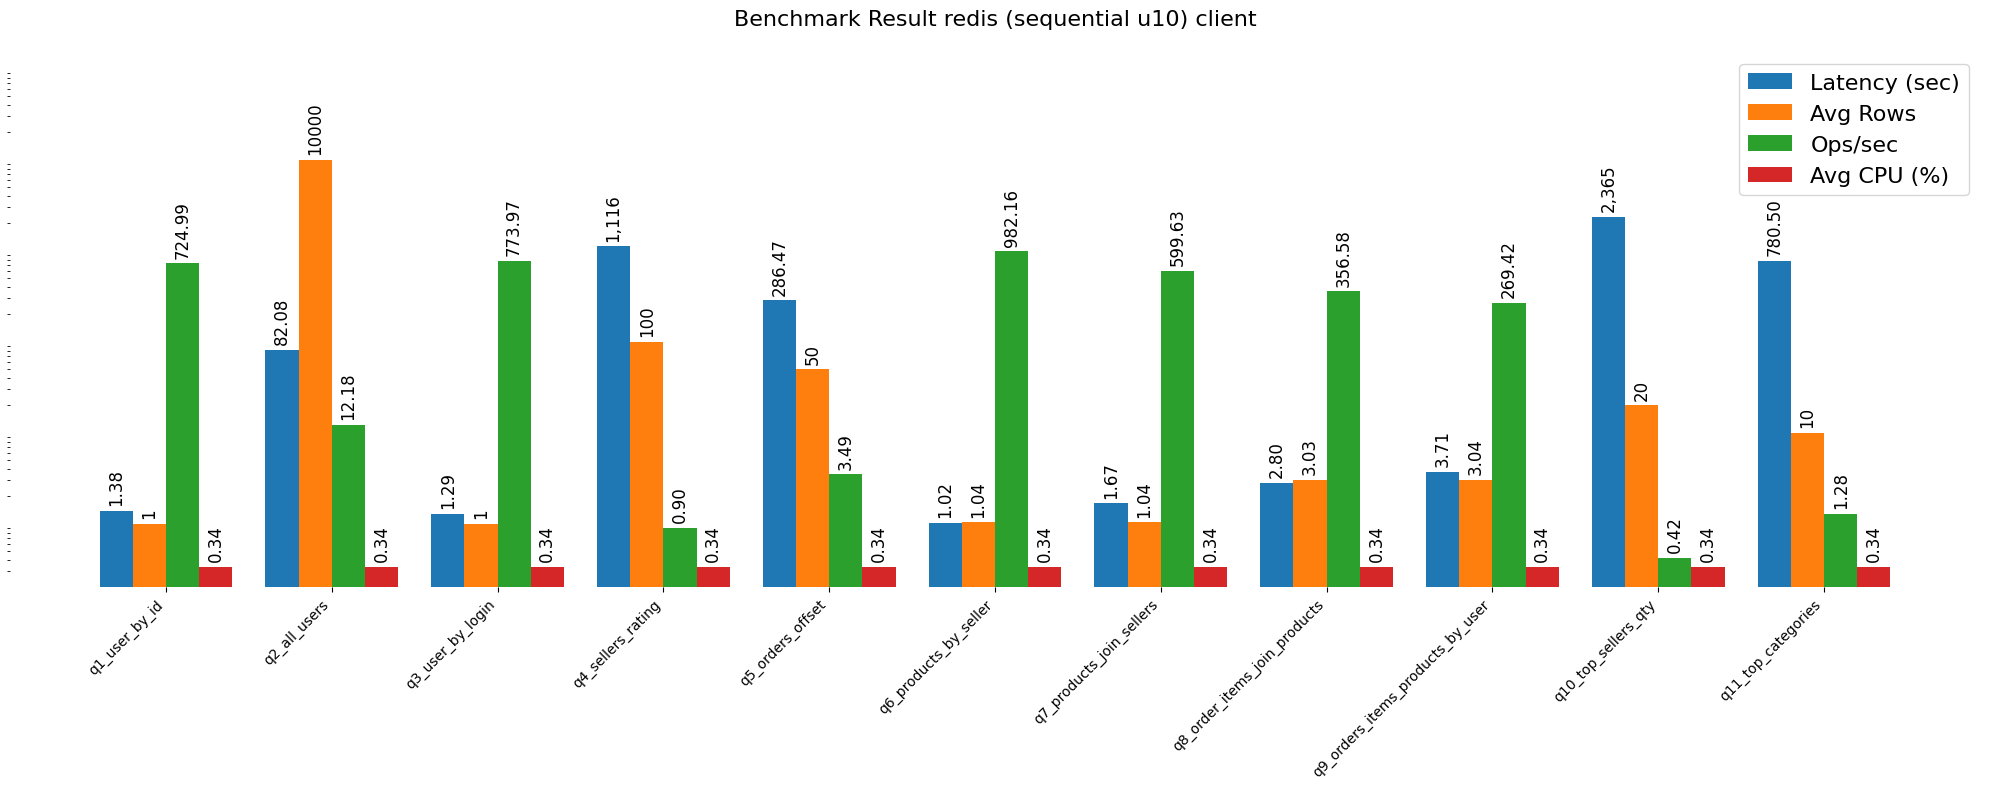

In [14]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

csv_path = Path("redis/redis (sequential u10)/phase_summary_client.csv")
df = pd.read_csv(csv_path)
folder_name = csv_path.parent.name

# Filter for the benchmark phase
df_benchmark = df[df['phase'] == 'benchmark']

# Create the bar chart
plt.figure(figsize=(20, 8))

# Define metrics to plot and their labels
metrics = ['duration_sec', 'avg_rows_returned', 'ops_per_sec', 'avg_cpu_percent']
labels = ['Latency (sec)', 'Avg Rows', 'Ops/sec', 'Avg CPU (%)']
# Используем яркие, насыщенные цвета
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# Set position of bar on X axis
bar_width = 0.2
x_indexes = np.arange(len(df_benchmark['query_name']))

# Plot each metric
bars_list = []
for i, metric in enumerate(metrics):
    pos = x_indexes + i * bar_width
    bars = plt.bar(pos, df_benchmark[metric], width=bar_width, color=colors[i], label=labels[i])
    bars_list.append(bars)

# Set dynamic title with folder name
plt.title(f'Benchmark Result {folder_name} client', fontsize=16, pad=20)

# Center the x-ticks in the middle of the 4 bars (the center is at 1.5 * bar_width)
plt.xticks(x_indexes + bar_width * 1.5, df_benchmark['query_name'], rotation=45, ha='right')

# Use logarithmic scale to show vastly different values together
plt.yscale('log')

# Добавляем динамический лимит, чтобы столбцы не наезжали на заголовок
max_y = df_benchmark[metrics].max().max()
if pd.notna(max_y) and max_y > 0:
    plt.ylim(top=max_y * 15)

# Remove y-axis ticks and labels
plt.xlabel('')
plt.ylabel('')
plt.yticks([])

# Remove borders (spines)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

# Add values above each bar
for metric_bars in bars_list:
    for bar in metric_bars:
        yval = bar.get_height()
        
        # Skip 0 or NaN values to avoid issues with log scale text placement
        if pd.isna(yval) or yval <= 0:
            continue
            
        if yval == int(yval):
            val_text = f'{int(yval)}'
        else:
            val_text = f'{yval:.2f}' if yval < 1000 else f'{yval:,.0f}'
        
        # In log scale, multiplying by a constant gives a uniform visual offset
        plt.text(bar.get_x() + bar.get_width()/2, yval * 1.15, val_text, ha='center', va='bottom', rotation=90, fontsize=12)

# Move legend to the top right, strictly inside the plot area
plt.legend(loc='upper right', fontsize=16)
plt.tight_layout()
plt.show()

Sequential percentily

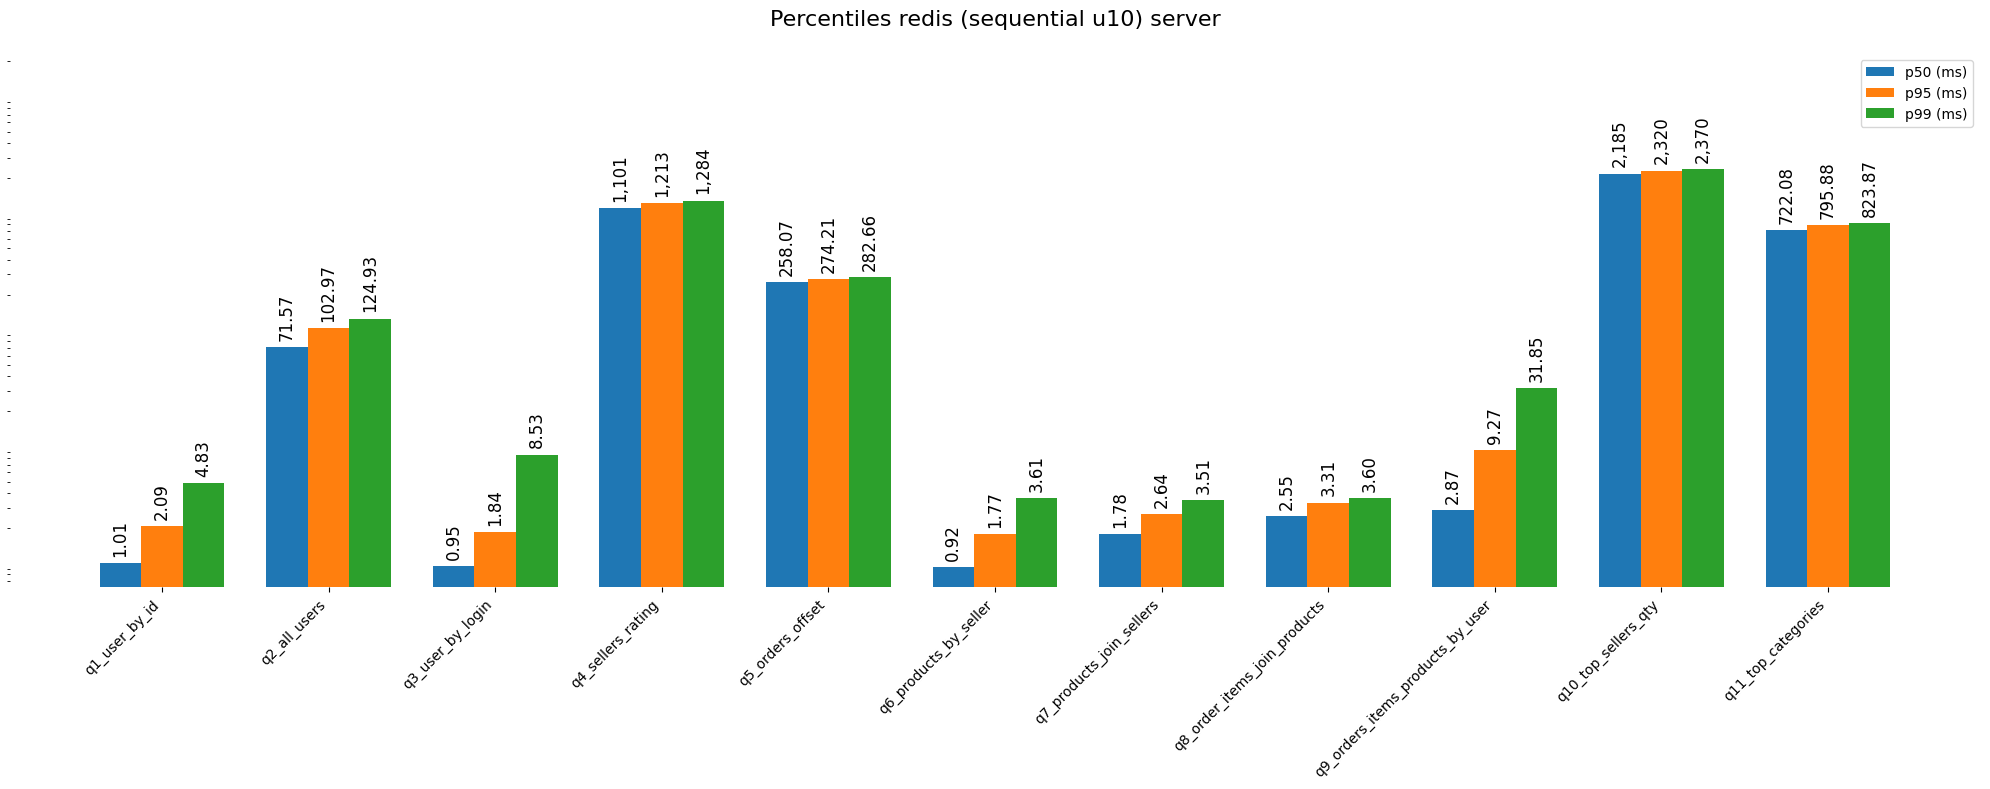

In [87]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

csv_path = Path("redis/redis (sequential u10)/phase_summary_server.csv")
df = pd.read_csv(csv_path)
folder_name = csv_path.parent.name

# Filter for the benchmark phase
df_benchmark = df[df['phase'] == 'benchmark']

# Create the bar chart
plt.figure(figsize=(20, 8))

# Define metrics to plot and their labels
metrics = ['p50_ms', 'p95_ms', 'p99_ms']
labels = ['p50 (ms)', 'p95 (ms)', 'p99 (ms)']
# Используем подходящие цвета для перцентилей
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# Set position of bar on X axis
bar_width = 0.25
x_indexes = np.arange(len(df_benchmark['query_name']))

# Plot each metric
bars_list = []
for i, metric in enumerate(metrics):
    pos = x_indexes + i * bar_width
    bars = plt.bar(pos, df_benchmark[metric], width=bar_width, color=colors[i], label=labels[i])
    bars_list.append(bars)

# Set dynamic title for percentiles
plt.title(f'Percentiles {folder_name} server', fontsize=16, pad=20)

# Center the x-ticks in the middle of the 3 bars (the center is at 1.0 * bar_width)
plt.xticks(x_indexes + bar_width, df_benchmark['query_name'], rotation=45, ha='right')

# Use logarithmic scale to show vastly different values together
plt.yscale('log')

# Добавляем пустое пространство сверху над графиком
max_y = df_benchmark[metrics].max().max()
if pd.notna(max_y) and max_y > 0:
    plt.ylim(top=max_y * 10)

# Remove y-axis ticks and labels
plt.xlabel('')
plt.ylabel('')
plt.yticks([])

# Remove borders (spines)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

# Add values above each bar
for metric_bars in bars_list:
    for bar in metric_bars:
        yval = bar.get_height()
        
        # Skip 0 or NaN values to avoid issues with log scale text placement
        if pd.isna(yval) or yval <= 0:
            continue
            
        if yval == int(yval):
            val_text = f'{int(yval)}'
        else:
            val_text = f'{yval:.2f}' if yval < 1000 else f'{yval:,.0f}'
        
        # In log scale, multiplying by a constant gives a uniform visual offset
        # Увеличили размер шрифта с 9 до 12
        plt.text(bar.get_x() + bar.get_width()/2, yval * 1.15, val_text, ha='center', va='bottom', rotation=90, fontsize=12)

# Move legend to the top right, strictly inside the plot area
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

сравнительный sequential (надо сделать для u1 и u10)

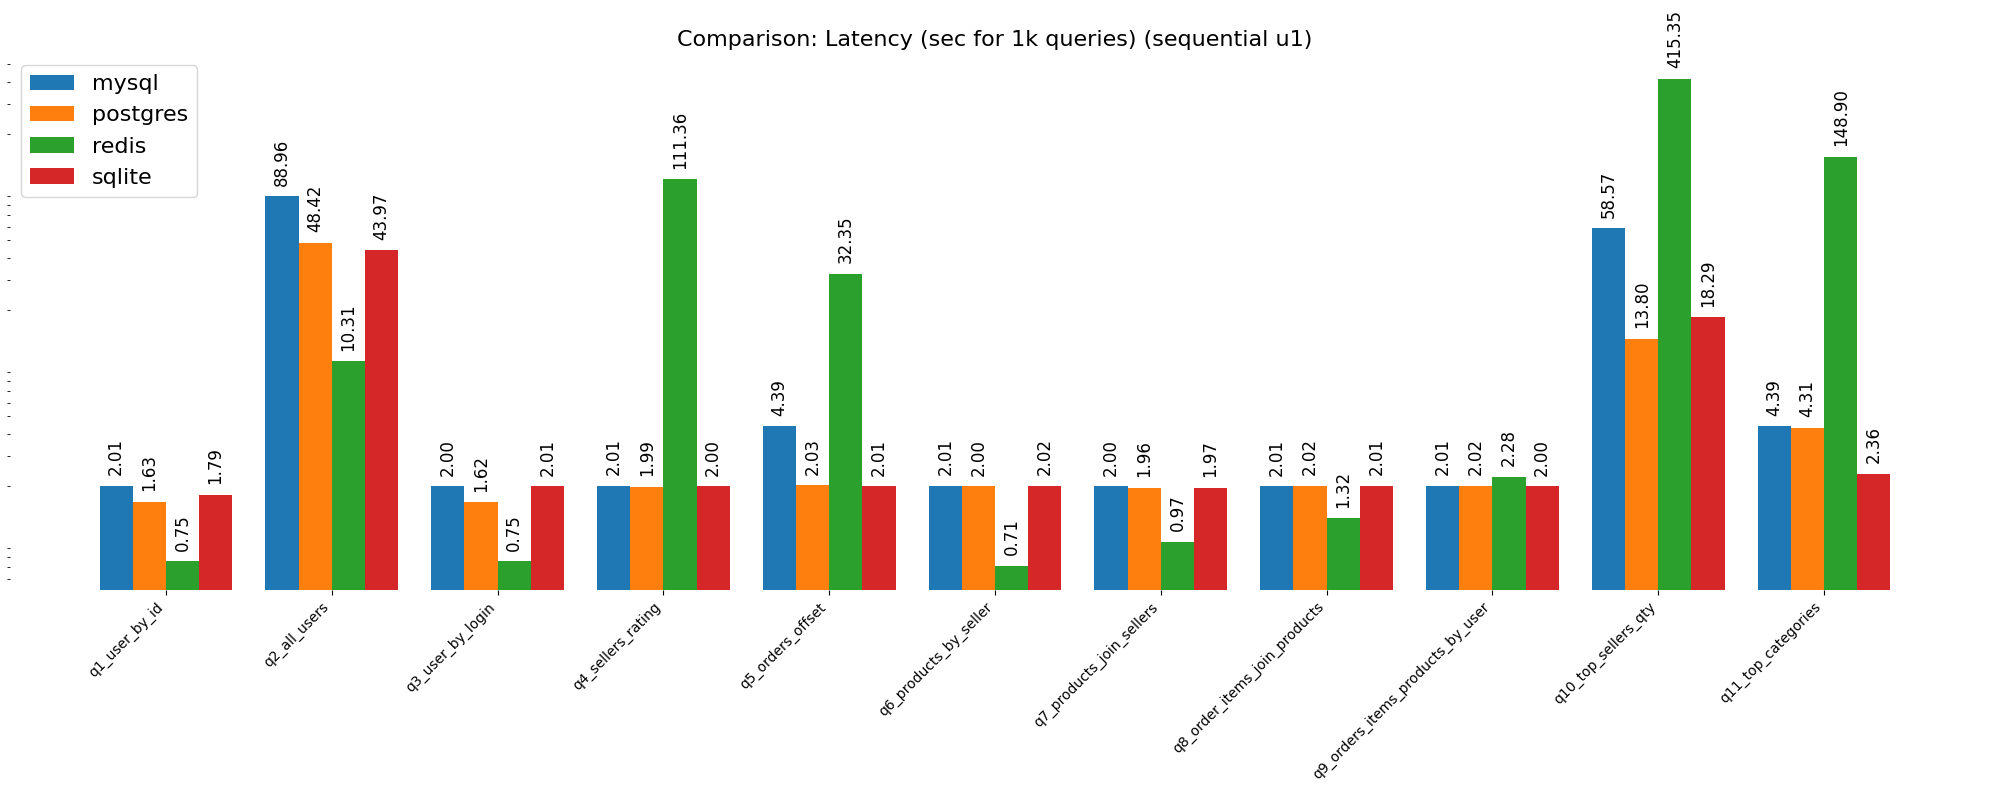

In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Список файлов для сравнения (sequential)
file_paths = [
    Path("mysql/mysql (sequential u1)/phase_summary.csv"),
    Path("postgres/postgres (sequential u1)/phase_summary.csv"),
    Path("redis/redis (sequential u1)/phase_summary_client.csv"),
    Path("sqlite/sqlite (sequential u1)/phase_summary.csv")
]

dfs = []
labels = []

# Считываем данные и строго фильтруем по фазе benchmark
for path in file_paths:
    df = pd.read_csv(path)
    
    # Приводим к нижнему регистру и убираем лишние пробелы для гарантии, что берем именно benchmark
    df_benchmark = df[df['phase'].astype(str).str.lower().str.strip() == 'benchmark'].copy()
    
    # Извлекаем число после q (например, 10 из q10_...) для естественной (числовой) сортировки
    df_benchmark['q_num'] = df_benchmark['query_name'].str.extract(r'q(\d+)').astype(int)
    df_benchmark = df_benchmark.sort_values('q_num').drop(columns=['q_num']).reset_index(drop=True)
    
    dfs.append(df_benchmark)
    
    # Берем первое слово из названия папки (mysql, postgres, и т.д.)
    db_name = path.parent.name.split()[0]
    labels.append(db_name)

# Собираем уникальные запросы 
query_names = dfs[0]['query_name'].values

plt.figure(figsize=(20, 8))

# Цвета для разных баз данных
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bar_width = 0.2
x_indexes = np.arange(len(query_names))

bars_list = []
# Строим столбцы для каждой базы данных (сравниваем duration_sec)
for i, df_bench in enumerate(dfs):
    pos = x_indexes + i * bar_width
    bars = plt.bar(pos, df_bench['duration_sec'], width=bar_width, color=colors[i], label=labels[i])
    bars_list.append(bars)

# Явно укажем в заголовке, что это фаза Benchmark
plt.title('Сomparison: Latency (sec for 1k queries) (sequential u1)', fontsize=16)

# Центрируем подписи по оси x (4 столбца)
plt.xticks(x_indexes + bar_width * 1.5, query_names, rotation=45, ha='right')

# Логарифмическая шкала
plt.yscale('log')

plt.xlabel('')
plt.ylabel('')
plt.yticks([])

# Убираем рамки
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

# Добавляем цифры над каждым столбиком
for metric_bars in bars_list:
    for bar in metric_bars:
        yval = bar.get_height()
        
        if pd.isna(yval) or yval <= 0:
            continue
            
        if yval == int(yval):
            val_text = f'{int(yval)}'
        else:
            val_text = f'{yval:.2f}' if yval < 1000 else f'{yval:,.0f}'
        
        plt.text(bar.get_x() + bar.get_width()/2, yval * 1.15, val_text, ha='center', va='bottom', rotation=90, fontsize=12)

plt.legend(loc='upper left', fontsize=16)
plt.tight_layout()
plt.show()

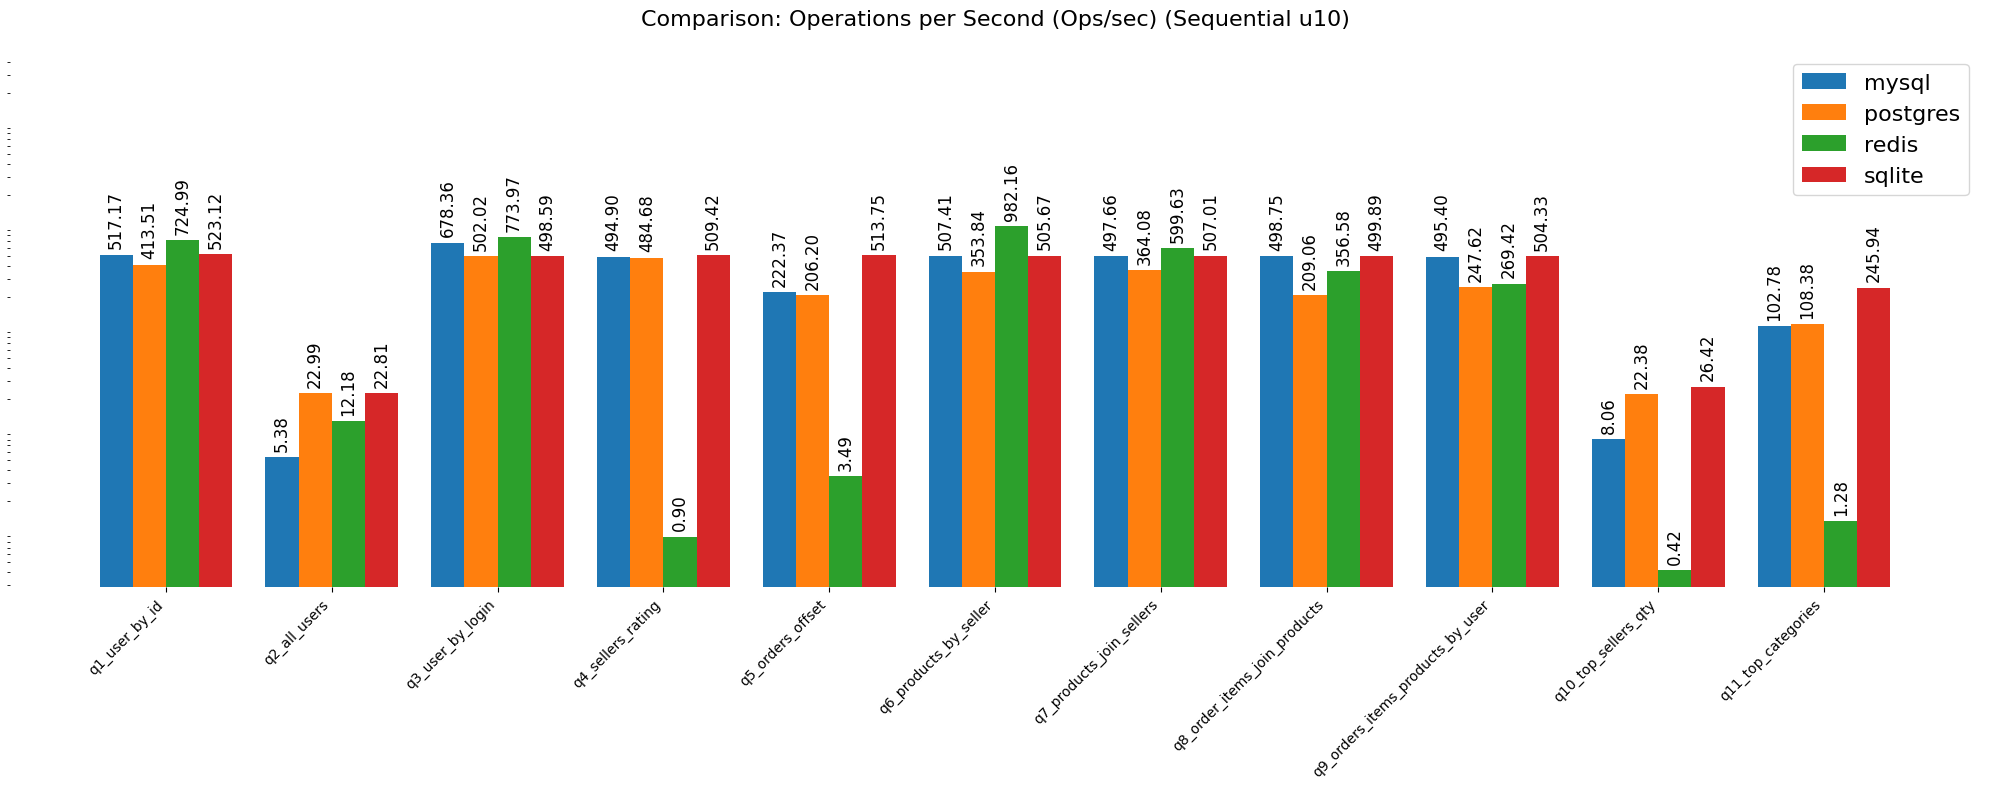

In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Список файлов для сравнения (sequential)
file_paths = [
    Path("mysql/mysql (sequential u10)/phase_summary.csv"),
    Path("postgres/postgres (sequential u10)/phase_summary.csv"),
    Path("redis/redis (sequential u10)/phase_summary_client.csv"),
    Path("sqlite/sqlite (sequential u10)/phase_summary.csv")
]

dfs = []
labels = []

# Считываем данные и строго фильтруем по фазе benchmark
for path in file_paths:
    df = pd.read_csv(path)
    
    # Приводим к нижнему регистру и убираем лишние пробелы для гарантии, что берем именно benchmark
    df_benchmark = df[df['phase'].astype(str).str.lower().str.strip() == 'benchmark'].copy()
    
    # Извлекаем число после q (например, 10 из q10_...) для естественной (числовой) сортировки
    df_benchmark['q_num'] = df_benchmark['query_name'].str.extract(r'q(\d+)').astype(int)
    df_benchmark = df_benchmark.sort_values('q_num').drop(columns=['q_num']).reset_index(drop=True)
    
    dfs.append(df_benchmark)
    
    # Берем первое слово из названия папки (mysql, postgres, и т.д.)
    db_name = path.parent.name.split()[0]
    labels.append(db_name)

# Собираем уникальные запросы 
query_names = dfs[0]['query_name'].values

plt.figure(figsize=(20, 8))

# Цвета для разных баз данных
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bar_width = 0.2
x_indexes = np.arange(len(query_names))

bars_list = []
max_y = 0

# Строим столбцы для каждой базы данных (сравниваем ops_per_sec)
for i, df_bench in enumerate(dfs):
    pos = x_indexes + i * bar_width
    bars = plt.bar(pos, df_bench['ops_per_sec'], width=bar_width, color=colors[i], label=labels[i])
    bars_list.append(bars)
    
    current_max = df_bench['ops_per_sec'].max()
    if pd.notna(current_max) and current_max > max_y:
        max_y = current_max

# Явно укажем в заголовке метрику Ops/sec и добавим отступ
plt.title('Comparison: Operations per Second (Ops/sec) (Sequential u10)', fontsize=16, pad=20)

# Центрируем подписи по оси x (4 столбца)
plt.xticks(x_indexes + bar_width * 1.5, query_names, rotation=45, ha='right')

# Логарифмическая шкала
plt.yscale('log')

# Увеличиваем лимит по оси Y, чтобы добавить пустое пространство над столбцами
if max_y > 0:
    plt.ylim(top=max_y * 50)

plt.xlabel('')
plt.ylabel('')
plt.yticks([])

# Убираем рамки
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

# Добавляем цифры над каждым столбиком
for metric_bars in bars_list:
    for bar in metric_bars:
        yval = bar.get_height()
        
        if pd.isna(yval) or yval <= 0:
            continue
            
        if yval == int(yval):
            val_text = f'{int(yval)}'
        else:
            val_text = f'{yval:.2f}' if yval < 1000 else f'{yval:,.0f}'
        
        plt.text(bar.get_x() + bar.get_width()/2, yval * 1.15, val_text, ha='center', va='bottom', rotation=90, fontsize=12)

# Увеличиваем размер шрифта легенды
plt.legend(loc='upper right', fontsize=16)
plt.tight_layout()
plt.show()

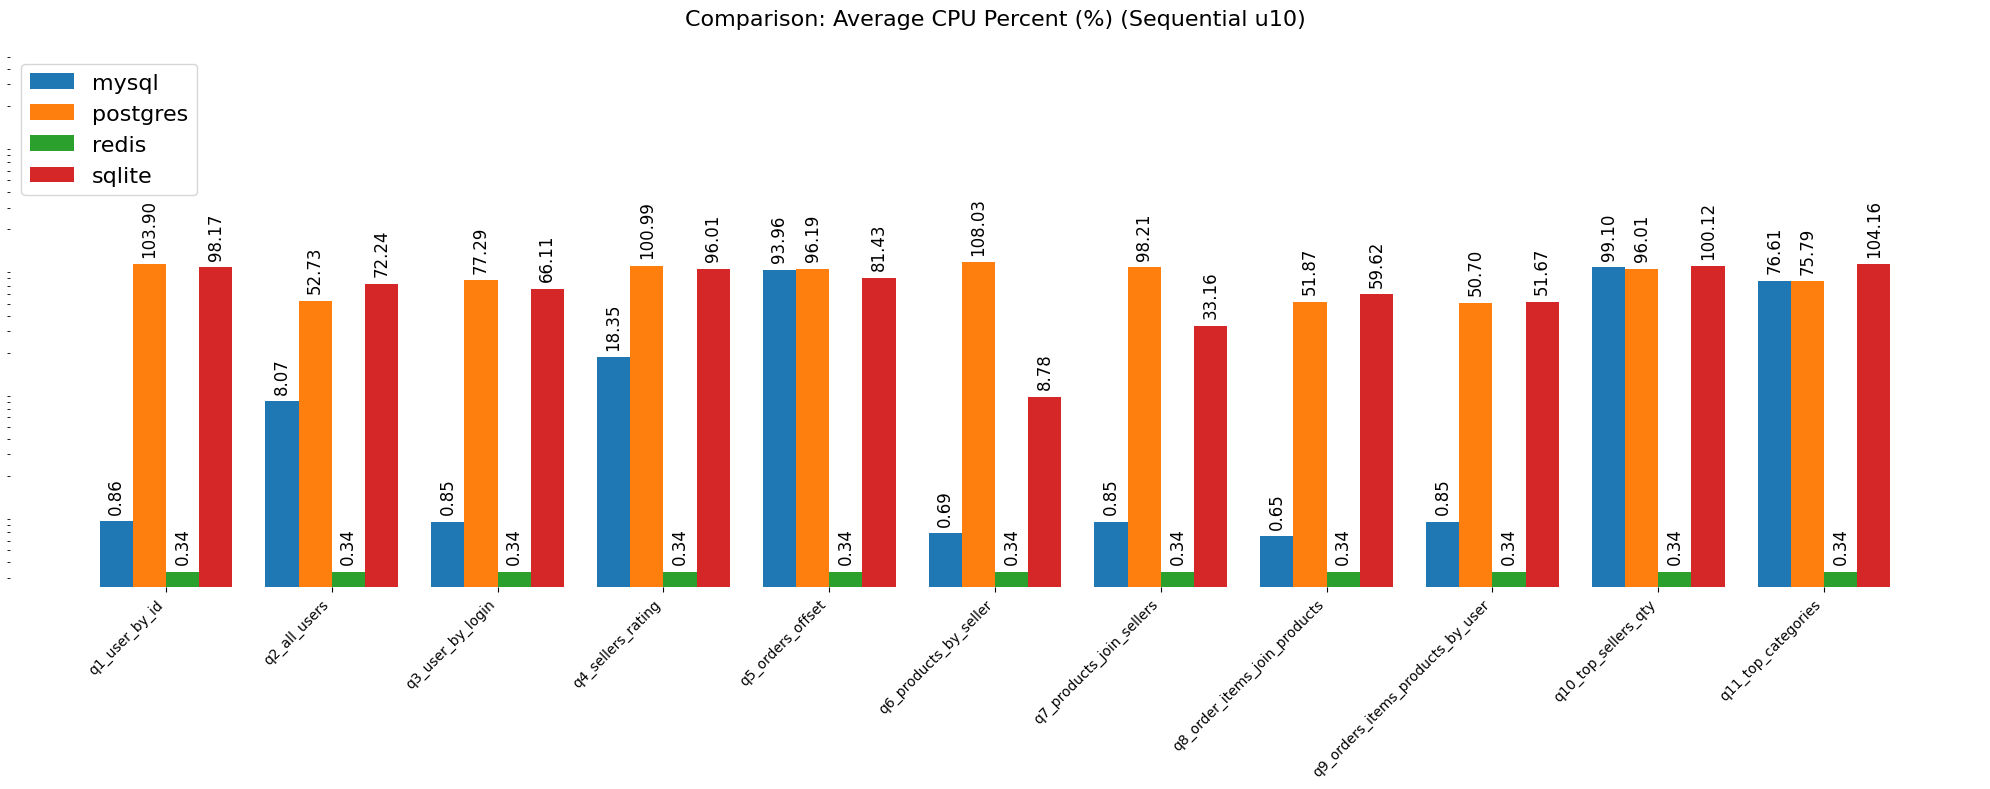

In [108]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Список файлов для сравнения (sequential)
file_paths = [
    Path("mysql/mysql (sequential u10)/phase_summary.csv"),
    Path("postgres/postgres (sequential u10)/phase_summary.csv"),
    Path("redis/redis (sequential u10)/phase_summary_client.csv"),
    Path("sqlite/sqlite (sequential u10)/phase_summary.csv")
]

dfs = []
labels = []

# Считываем данные и строго фильтруем по фазе benchmark
for path in file_paths:
    df = pd.read_csv(path)
    
    # Приводим к нижнему регистру и убираем лишние пробелы для гарантии, что берем именно benchmark
    df_benchmark = df[df['phase'].astype(str).str.lower().str.strip() == 'benchmark'].copy()
    
    # Извлекаем число после q (например, 10 из q10_...) для естественной (числовой) сортировки
    df_benchmark['q_num'] = df_benchmark['query_name'].str.extract(r'q(\d+)').astype(int)
    df_benchmark = df_benchmark.sort_values('q_num').drop(columns=['q_num']).reset_index(drop=True)
    
    dfs.append(df_benchmark)
    
    # Берем первое слово из названия папки (mysql, postgres, и т.д.)
    db_name = path.parent.name.split()[0]
    labels.append(db_name)

# Собираем уникальные запросы 
query_names = dfs[0]['query_name'].values

plt.figure(figsize=(20, 8))

# Цвета для разных баз данных
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bar_width = 0.2
x_indexes = np.arange(len(query_names))

bars_list = []
max_y = 0

# Строим столбцы для каждой базы данных (сравниваем avg_cpu_percent)
for i, df_bench in enumerate(dfs):
    pos = x_indexes + i * bar_width
    bars = plt.bar(pos, df_bench['avg_cpu_percent'], width=bar_width, color=colors[i], label=labels[i])
    bars_list.append(bars)
    
    current_max = df_bench['avg_cpu_percent'].max()
    if pd.notna(current_max) and current_max > max_y:
        max_y = current_max

# Явно укажем в заголовке метрику Avg CPU и добавим отступ
plt.title('Comparison: Average CPU Percent (%) (Sequential u10)', fontsize=16, pad=20)

# Центрируем подписи по оси x (4 столбца)
plt.xticks(x_indexes + bar_width * 1.5, query_names, rotation=45, ha='right')

# Логарифмическая шкала
plt.yscale('log')

# Увеличиваем лимит по оси Y, чтобы добавить пустое пространство над столбцами
if max_y > 0:
    plt.ylim(top=max_y * 50)

plt.xlabel('')
plt.ylabel('')
plt.yticks([])

# Убираем рамки
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

# Добавляем цифры над каждым столбиком
for metric_bars in bars_list:
    for bar in metric_bars:
        yval = bar.get_height()
        
        if pd.isna(yval) or yval <= 0:
            continue
            
        if yval == int(yval):
            val_text = f'{int(yval)}'
        else:
            val_text = f'{yval:.2f}' if yval < 1000 else f'{yval:,.0f}'
        
        plt.text(bar.get_x() + bar.get_width()/2, yval * 1.15, val_text, ha='center', va='bottom', rotation=90, fontsize=12)

plt.legend(loc='upper left', fontsize=16)
plt.tight_layout()
plt.show()

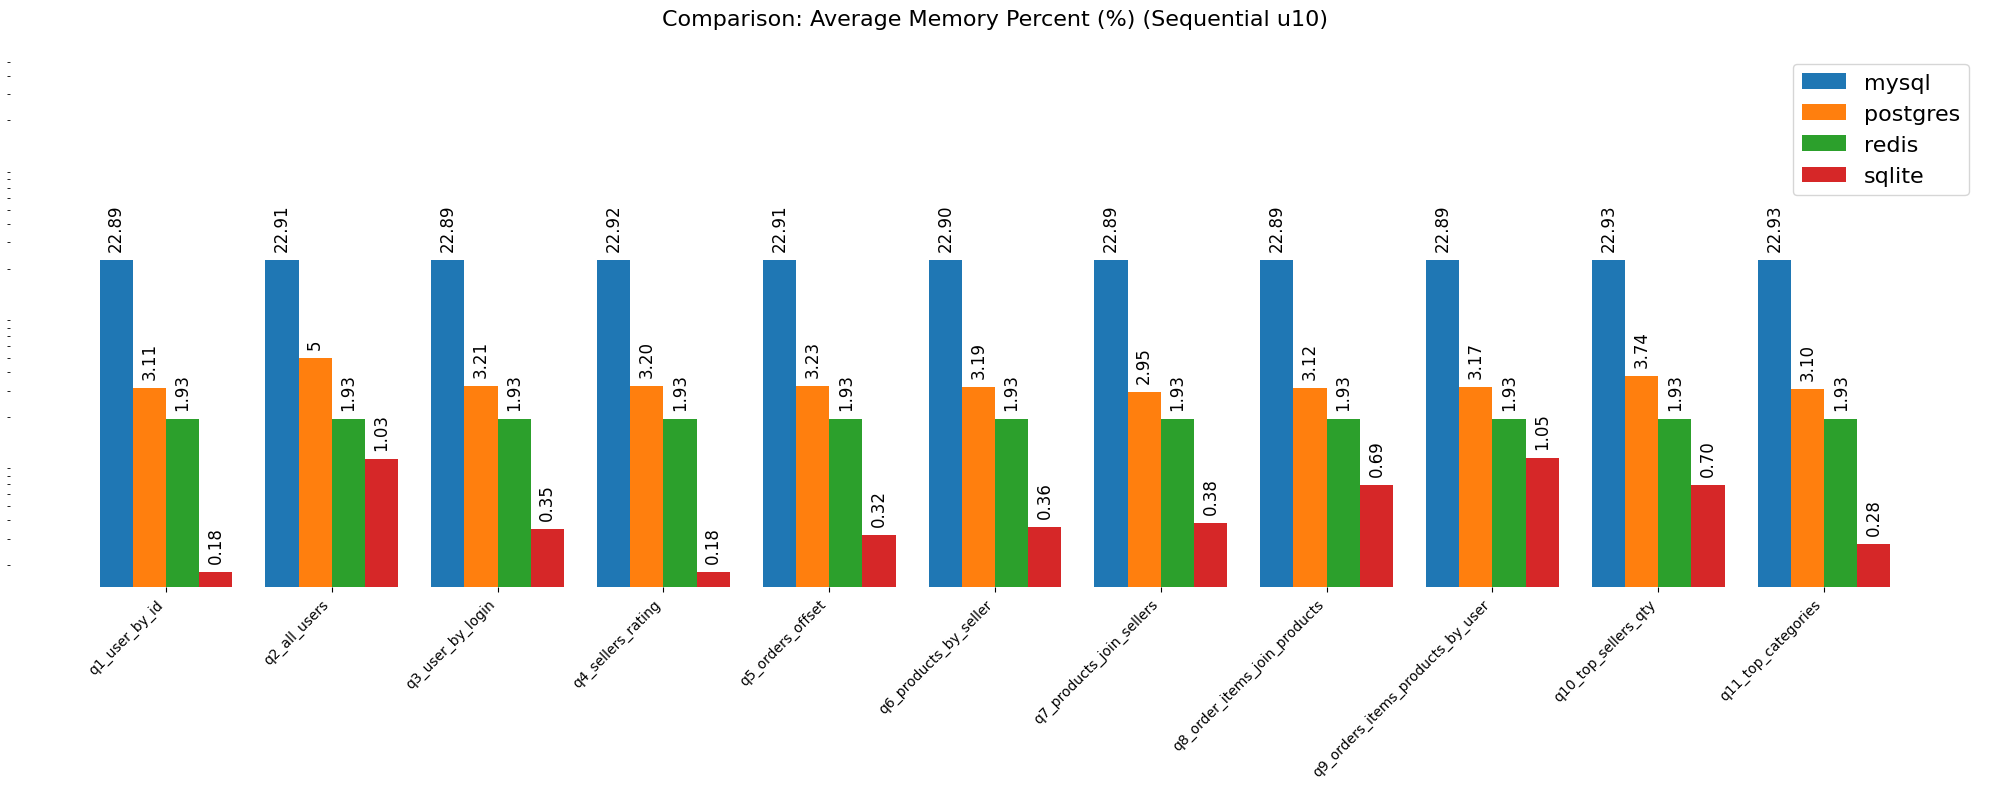

In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Список файлов для сравнения (sequential)
file_paths = [
    Path("mysql/mysql (sequential u10)/phase_summary.csv"),
    Path("postgres/postgres (sequential u10)/phase_summary.csv"),
    Path("redis/redis (sequential u10)/phase_summary_client.csv"),
    Path("sqlite/sqlite (sequential u10)/phase_summary.csv")
]

dfs = []
labels = []

# Считываем данные и строго фильтруем по фазе benchmark
for path in file_paths:
    df = pd.read_csv(path)
    
    # Приводим к нижнему регистру и убираем лишние пробелы для гарантии, что берем именно benchmark
    df_benchmark = df[df['phase'].astype(str).str.lower().str.strip() == 'benchmark'].copy()
    
    # Извлекаем число после q (например, 10 из q10_...) для естественной (числовой) сортировки
    df_benchmark['q_num'] = df_benchmark['query_name'].str.extract(r'q(\d+)').astype(int)
    df_benchmark = df_benchmark.sort_values('q_num').drop(columns=['q_num']).reset_index(drop=True)
    
    dfs.append(df_benchmark)
    
    # Берем первое слово из названия папки (mysql, postgres, и т.д.)
    db_name = path.parent.name.split()[0]
    labels.append(db_name)

# Собираем уникальные запросы 
query_names = dfs[0]['query_name'].values

plt.figure(figsize=(20, 8))

# Цвета для разных баз данных
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bar_width = 0.2
x_indexes = np.arange(len(query_names))

bars_list = []
max_y = 0

# Строим столбцы для каждой базы данных (сравниваем avg_mem_percent)
for i, df_bench in enumerate(dfs):
    pos = x_indexes + i * bar_width
    bars = plt.bar(pos, df_bench['avg_mem_percent'], width=bar_width, color=colors[i], label=labels[i])
    bars_list.append(bars)
    
    current_max = df_bench['avg_mem_percent'].max()
    if pd.notna(current_max) and current_max > max_y:
        max_y = current_max

# Явно укажем в заголовке метрику Avg Memory и добавим отступ
plt.title('Comparison: Average Memory Percent (%) (Sequential u10)', fontsize=16, pad=20)

# Центрируем подписи по оси x (4 столбца)
plt.xticks(x_indexes + bar_width * 1.5, query_names, rotation=45, ha='right')

# Логарифмическая шкала
plt.yscale('log')

# Увеличиваем лимит по оси Y, чтобы добавить пустое пространство над столбцами
if max_y > 0:
    plt.ylim(top=max_y * 25)

plt.xlabel('')
plt.ylabel('')
plt.yticks([])

# Убираем рамки
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

# Добавляем цифры над каждым столбиком
for metric_bars in bars_list:
    for bar in metric_bars:
        yval = bar.get_height()
        
        if pd.isna(yval) or yval <= 0:
            continue
            
        if yval == int(yval):
            val_text = f'{int(yval)}'
        else:
            val_text = f'{yval:.2f}' if yval < 1000 else f'{yval:,.0f}'
        
        plt.text(bar.get_x() + bar.get_width()/2, yval * 1.15, val_text, ha='center', va='bottom', rotation=90, fontsize=12)

plt.legend(loc='upper right', fontsize=16)
plt.tight_layout()
plt.show()

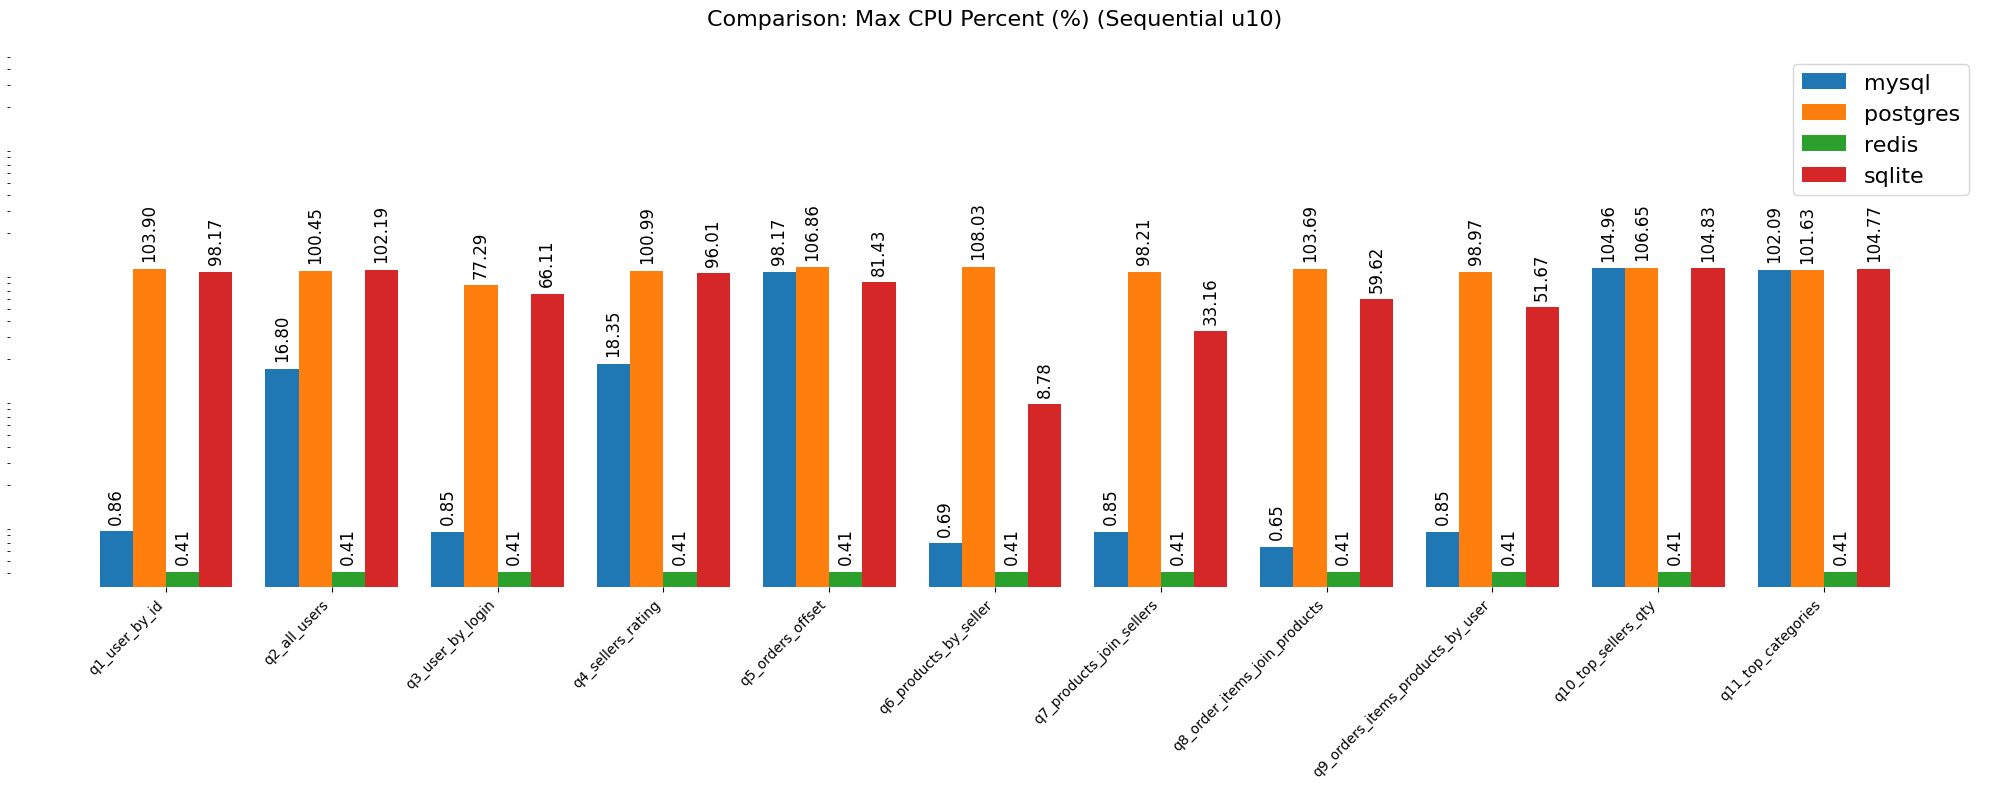

In [115]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Список файлов для сравнения (sequential)
file_paths = [
    Path("mysql/mysql (sequential u10)/phase_summary.csv"),
    Path("postgres/postgres (sequential u10)/phase_summary.csv"),
    Path("redis/redis (sequential u10)/phase_summary_client.csv"),
    Path("sqlite/sqlite (sequential u10)/phase_summary.csv")
]

dfs = []
labels = []

# Считываем данные и строго фильтруем по фазе benchmark
for path in file_paths:
    df = pd.read_csv(path)
    
    # Приводим к нижнему регистру и убираем лишние пробелы для гарантии, что берем именно benchmark
    df_benchmark = df[df['phase'].astype(str).str.lower().str.strip() == 'benchmark'].copy()
    
    # Извлекаем число после q (например, 10 из q10_...) для естественной (числовой) сортировки
    df_benchmark['q_num'] = df_benchmark['query_name'].str.extract(r'q(\d+)').astype(int)
    df_benchmark = df_benchmark.sort_values('q_num').drop(columns=['q_num']).reset_index(drop=True)
    
    dfs.append(df_benchmark)
    
    # Берем первое слово из названия папки (mysql, postgres, и т.д.)
    db_name = path.parent.name.split()[0]
    labels.append(db_name)

# Собираем уникальные запросы 
query_names = dfs[0]['query_name'].values

plt.figure(figsize=(20, 8))

# Цвета для разных баз данных
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bar_width = 0.2
x_indexes = np.arange(len(query_names))

bars_list = []
max_y = 0

# Строим столбцы для каждой базы данных (сравниваем max_cpu_percent)
for i, df_bench in enumerate(dfs):
    pos = x_indexes + i * bar_width
    bars = plt.bar(pos, df_bench['max_cpu_percent'], width=bar_width, color=colors[i], label=labels[i])
    bars_list.append(bars)
    
    current_max = df_bench['max_cpu_percent'].max()
    if pd.notna(current_max) and current_max > max_y:
        max_y = current_max

# Явно укажем в заголовке метрику Max CPU и добавим отступ
plt.title('Comparison: Max CPU Percent (%) (Sequential u10)', fontsize=16, pad=20)

# Центрируем подписи по оси x (4 столбца)
plt.xticks(x_indexes + bar_width * 1.5, query_names, rotation=45, ha='right')

# Логарифмическая шкала
plt.yscale('log')

# Увеличиваем лимит по оси Y, чтобы добавить пустое пространство над столбцами
if max_y > 0:
    plt.ylim(top=max_y * 50)

plt.xlabel('')
plt.ylabel('')
plt.yticks([])

# Убираем рамки
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

# Добавляем цифры над каждым столбиком
for metric_bars in bars_list:
    for bar in metric_bars:
        yval = bar.get_height()
        
        if pd.isna(yval) or yval <= 0:
            continue
            
        if yval == int(yval):
            val_text = f'{int(yval)}'
        else:
            val_text = f'{yval:.2f}' if yval < 1000 else f'{yval:,.0f}'
        
        plt.text(bar.get_x() + bar.get_width()/2, yval * 1.15, val_text, ha='center', va='bottom', rotation=90, fontsize=12)

plt.legend(loc='upper right', fontsize=16)
plt.tight_layout()
plt.show()

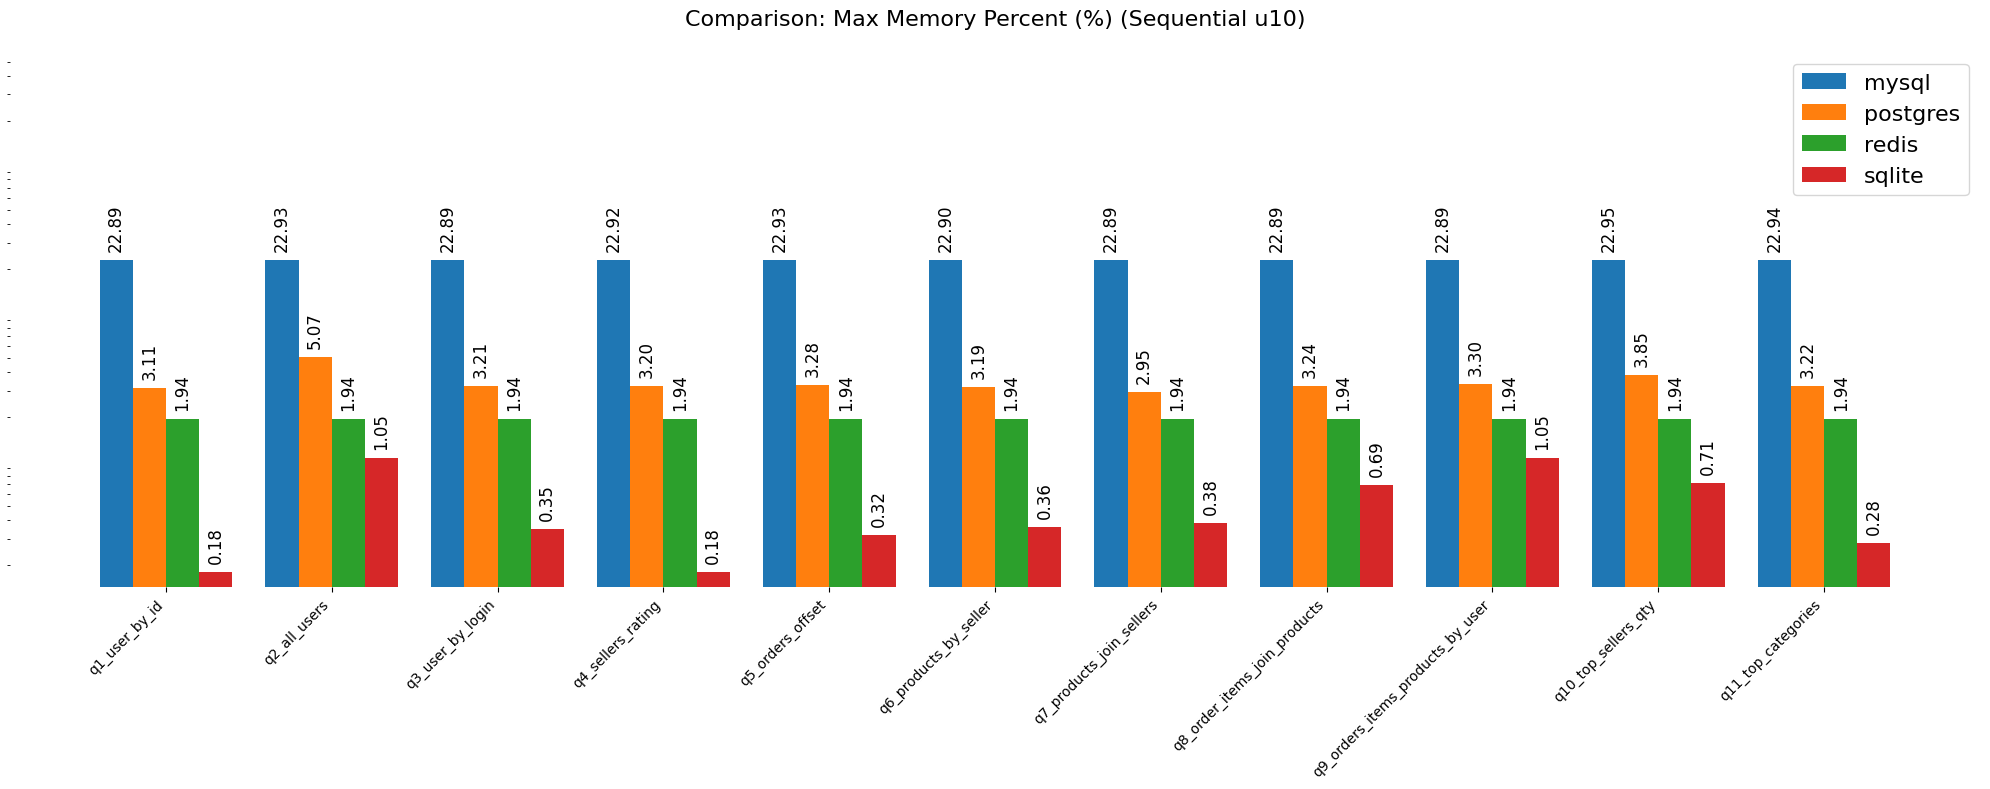

In [117]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Список файлов для сравнения (sequential)
file_paths = [
    Path("mysql/mysql (sequential u10)/phase_summary.csv"),
    Path("postgres/postgres (sequential u10)/phase_summary.csv"),
    Path("redis/redis (sequential u10)/phase_summary_client.csv"),
    Path("sqlite/sqlite (sequential u10)/phase_summary.csv")
]

dfs = []
labels = []

# Считываем данные и строго фильтруем по фазе benchmark
for path in file_paths:
    df = pd.read_csv(path)
    
    # Приводим к нижнему регистру и убираем лишние пробелы для гарантии, что берем именно benchmark
    df_benchmark = df[df['phase'].astype(str).str.lower().str.strip() == 'benchmark'].copy()
    
    # Извлекаем число после q (например, 10 из q10_...) для естественной (числовой) сортировки
    df_benchmark['q_num'] = df_benchmark['query_name'].str.extract(r'q(\d+)').astype(int)
    df_benchmark = df_benchmark.sort_values('q_num').drop(columns=['q_num']).reset_index(drop=True)
    
    dfs.append(df_benchmark)
    
    # Берем первое слово из названия папки (mysql, postgres, и т.д.)
    db_name = path.parent.name.split()[0]
    labels.append(db_name)

# Собираем уникальные запросы 
query_names = dfs[0]['query_name'].values

plt.figure(figsize=(20, 8))

# Цвета для разных баз данных
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bar_width = 0.2
x_indexes = np.arange(len(query_names))

bars_list = []
max_y = 0

# Строим столбцы для каждой базы данных (сравниваем max_mem_percent)
for i, df_bench in enumerate(dfs):
    pos = x_indexes + i * bar_width
    bars = plt.bar(pos, df_bench['max_mem_percent'], width=bar_width, color=colors[i], label=labels[i])
    bars_list.append(bars)
    
    current_max = df_bench['max_mem_percent'].max()
    if pd.notna(current_max) and current_max > max_y:
        max_y = current_max

# Явно укажем в заголовке метрику Max Memory и добавим отступ
plt.title('Comparison: Max Memory Percent (%) (Sequential u10)', fontsize=16, pad=20)

# Центрируем подписи по оси x (4 столбца)
plt.xticks(x_indexes + bar_width * 1.5, query_names, rotation=45, ha='right')

# Логарифмическая шкала
plt.yscale('log')

# Увеличиваем лимит по оси Y, чтобы добавить пустое пространство над столбцами
if max_y > 0:
    plt.ylim(top=max_y * 25)

plt.xlabel('')
plt.ylabel('')
plt.yticks([])

# Убираем рамки
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

# Добавляем цифры над каждым столбиком
for metric_bars in bars_list:
    for bar in metric_bars:
        yval = bar.get_height()
        
        if pd.isna(yval) or yval <= 0:
            continue
            
        if yval == int(yval):
            val_text = f'{int(yval)}'
        else:
            val_text = f'{yval:.2f}' if yval < 1000 else f'{yval:,.0f}'
        
        plt.text(bar.get_x() + bar.get_width()/2, yval * 1.15, val_text, ha='center', va='bottom', rotation=90, fontsize=12)

plt.legend(loc='upper right', fontsize=16)
plt.tight_layout()
plt.show()

сравнительный mixed (Сдлеать для u1/u10)

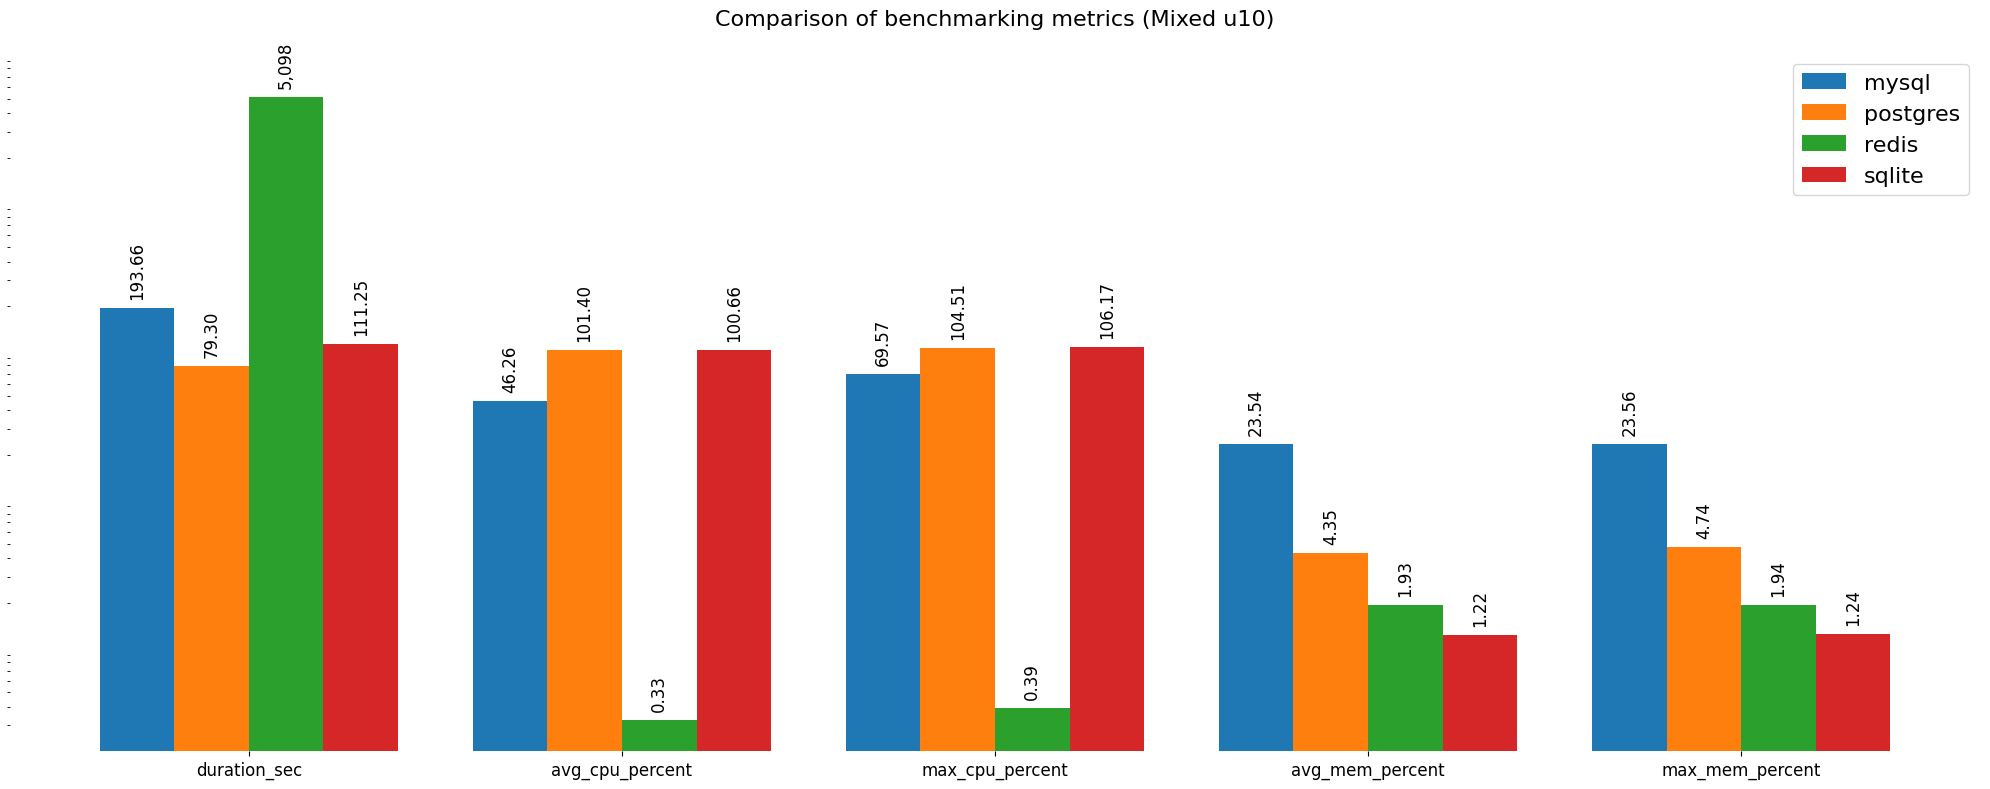

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Список файлов для сравнения (sequential)
file_paths = [
    Path("mysql/mysql (mixed u1)/phase_summary.csv"),
    Path("postgres/postgres (mixed u1)/phase_summary.csv"),
    Path("redis/redis (mixed u1)/phase_summary_client.csv"),
    Path("sqlite/sqlite (mixed u1)/phase_summary.csv")
]

db_data = []
labels = []
metrics = ['duration_sec', 'avg_cpu_percent', 'max_cpu_percent', 'avg_mem_percent', 'max_mem_percent']

# Считываем данные и строго фильтруем по фазе benchmark и конкретному запросу
for path in file_paths:
    df = pd.read_csv(path)
    
    # Оставляем только benchmark и нужный запрос
    mask = (df['phase'].astype(str).str.lower().str.strip() == 'benchmark') & \
           (df['query_name'].astype(str).str.strip() == 'q1_user_by_id')
    
    df_filtered = df[mask]
    
    if not df_filtered.empty:
        # Извлекаем значения конкретных полей для этого запроса
        values = df_filtered.iloc[0][metrics].tolist()
    else:
        values = [0, 0, 0, 0, 0]
        
    db_data.append(values)
    
    # Берем первое слово из названия папки (mysql, postgres, и т.д.)
    db_name = path.parent.name.split()[0]
    labels.append(db_name)

plt.figure(figsize=(20, 8))

# Цвета для разных баз данных
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bar_width = 0.2
x_indexes = np.arange(len(metrics))

bars_list = []
max_y = 0

# Строим столбцы для каждой базы данных (сравниваем разные метрики)
for i, values in enumerate(db_data):
    pos = x_indexes + i * bar_width
    bars = plt.bar(pos, values, width=bar_width, color=colors[i], label=labels[i])
    bars_list.append(bars)
    
    # Ищем максимум для корректного отображения логарифмической шкалы
    current_max = max([v for v in values if pd.notna(v)] or [0])
    if current_max > max_y:
        max_y = current_max

# Заголовок
plt.title('Comparison of benchmarking metrics (Mixed u1)', fontsize=16, pad=20)

# Выводим названия полей по оси X
plt.xticks(x_indexes + bar_width * 1.5, metrics, rotation=0, ha='center', fontsize=12)

# Логарифмическая шкала остаётся, её удобно использовать для разных размерностей
plt.yscale('log')

# Увеличиваем лимит по оси Y, чтобы добавить пустое пространство над столбцами
if max_y > 0:
    plt.ylim(top=max_y * 2)

plt.xlabel('')
plt.ylabel('')
plt.yticks([])

# Убираем рамки
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

# Добавляем цифры над каждым столбиком
for metric_bars in bars_list:
    for bar in metric_bars:
        yval = bar.get_height()
        
        if pd.isna(yval) or yval <= 0:
            continue
            
        if yval == int(yval):
            val_text = f'{int(yval)}'
        else:
            val_text = f'{yval:.2f}' if yval < 1000 else f'{yval:,.0f}'
        
        plt.text(bar.get_x() + bar.get_width()/2, yval * 1.15, val_text, ha='center', va='bottom', rotation=90, fontsize=12)

plt.legend(loc='upper right', fontsize = 16)
plt.tight_layout()
plt.show()